# Exercise 9: Monte Carlo Method - Custom Grid World

This notebook implements a user-defined 4x4 Grid World and applies First-Visit Monte Carlo learning with an epsilon-greedy policy to learn $Q(s,a)$ and derive the optimal policy.

Grid layout:

S F F F
F H F H
F F F H
H F F G

## a) Custom Grid World Environment

State indexing is row-major (0-15). Actions: 0=Left, 1=Down, 2=Right, 3=Up.

In [1]:
import numpy as np
import random
from collections import defaultdict

# Grid definition
grid = [
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
]

n_rows, n_cols = 4, 4
n_states = n_rows * n_cols
n_actions = 4  # 0=Left, 1=Down, 2=Right, 3=Up

terminal_states = set()
start_state = 0
goal_state = None

for r in range(n_rows):
    for c in range(n_cols):
        cell = grid[r][c]
        s = r * n_cols + c
        if cell == 'S':
            start_state = s
        if cell == 'G':
            goal_state = s
            terminal_states.add(s)
        if cell == 'H':
            terminal_states.add(s)

def step(state, action):
    # If terminal, remain in terminal state
    if state in terminal_states:
        return state, 0.0, True

    r, c = divmod(state, n_cols)
    if action == 0:  # Left
        c2 = max(c - 1, 0)
        r2 = r
    elif action == 1:  # Down
        r2 = min(r + 1, n_rows - 1)
        c2 = c
    elif action == 2:  # Right
        c2 = min(c + 1, n_cols - 1)
        r2 = r
    else:  # Up
        r2 = max(r - 1, 0)
        c2 = c

    next_state = r2 * n_cols + c2
    next_cell = grid[r2][c2]
    reward = 1.0 if next_state == goal_state else 0.0
    done = next_state in terminal_states
    return next_state, reward, done

def reset():
    return start_state

## b) First-Visit Monte Carlo with Epsilon-Greedy Policy

In [2]:
# Q(s,a) and Returns storage
Q = np.zeros((n_states, n_actions))
returns = defaultdict(list)

# Hyperparameters
episodes = 20000
gamma = 0.95

epsilon = 1.0
epsilon_decay = 0.9995
epsilon_min = 0.05

def epsilon_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    return int(np.argmax(Q[state]))

print('Training using First-Visit Monte Carlo...')

for ep in range(episodes):
    episode = []  # (state, action, reward)
    state = reset()
    done = False

    # Generate episode
    while not done:
        action = epsilon_greedy(state)
        next_state, reward, done = step(state, action)
        episode.append((state, action, reward))
        state = next_state

    # Compute returns (backward)
    G = 0.0
    visited = set()
    for t in reversed(range(len(episode))):
        state_t, action_t, reward_t = episode[t]
        G = gamma * G + reward_t
        if (state_t, action_t) not in visited:
            visited.add((state_t, action_t))
            returns[(state_t, action_t)].append(G)
            Q[state_t, action_t] = np.mean(returns[(state_t, action_t)])

    # Decay exploration
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (ep + 1) % 5000 == 0:
        print(f'Episode {ep+1}/{episodes}, Epsilon={epsilon:.4f}')

print('Training complete.')

Training using First-Visit Monte Carlo...
Episode 5000/20000, Epsilon=0.0820
Episode 10000/20000, Epsilon=0.0500
Episode 15000/20000, Epsilon=0.0500
Episode 20000/20000, Epsilon=0.0500
Training complete.


## c) Optimal Policy from Learned $Q(s,a)$

Policy is shown as L/D/R/U for each grid cell (terminal states shown as H or G).

In [3]:
policy = np.argmax(Q, axis=1)
action_map = {0: 'L', 1: 'D', 2: 'R', 3: 'U'}

print('Learned Policy (4x4 Grid):')

for r in range(n_rows):
    row = []
    for c in range(n_cols):
        s = r * n_cols + c
        cell = grid[r][c]
        if cell == 'H':
            row.append('H')
        elif cell == 'G':
            row.append('G')
        elif cell == 'S':
            row.append(action_map[policy[s]])
        else:
            row.append(action_map[policy[s]])
    print(' '.join(row))

Learned Policy (4x4 Grid):
D R D L
D H D H
R D D H
H R R G


In [4]:
# d) Greedy rollout visualization (text-based)
max_steps = 30
state = reset()
path = [state]
done = False

for _ in range(max_steps):
    if state in terminal_states:
        break
    action = int(np.argmax(Q[state]))
    next_state, reward, done = step(state, action)
    path.append(next_state)
    state = next_state
    if done:
        break

print('Greedy path (state indices):', path)
print('Reached goal:', path[-1] == goal_state)

Greedy path (state indices): [0, 4, 8, 9, 13, 14, 15]
Reached goal: True


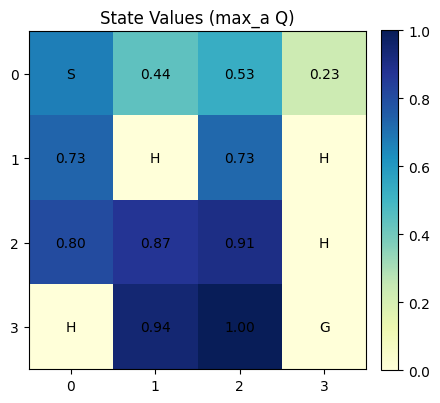

In [5]:
# Visualization: state-value heatmap from Q
import matplotlib.pyplot as plt

state_values = np.max(Q, axis=1).reshape(n_rows, n_cols)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(state_values, cmap='YlGnBu')
ax.set_title('State Values (max_a Q)')
ax.set_xticks(range(n_cols))
ax.set_yticks(range(n_rows))

for r in range(n_rows):
    for c in range(n_cols):
        cell = grid[r][c]
        if cell in ('H', 'G', 'S'):
            label = cell
        else:
            label = f"{state_values[r, c]:.2f}"
        ax.text(c, r, label, ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Training started...
Episode 10000 completed.
Episode 20000 completed.
Episode 30000 completed.
Episode 40000 completed.
Episode 50000 completed.
Training finished.

Optimal greedy policy:
[['→' '→' '↓' '←']
 ['↓' 'H' '↓' 'H']
 ['→' '→' '↓' 'H']
 ['H' '→' '→' 'G']]


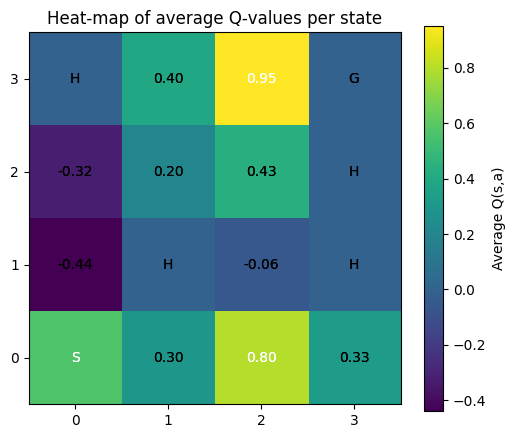

In [1]:
# ------------------------------------------------------------
# 1. GridWorld environment
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

class GridWorld:
    """
    4×4 grid world with the layout:

        S  F  F  F
        F  H  F  H
        F  F  F  H
        H  F  F  G

    Actions: 0=Left, 1=Down, 2=Right, 3=Up
    """
    def __init__(self):
        self.grid = np.array([
            ['S','F','F','F'],
            ['F','H','F','H'],
            ['F','F','F','H'],
            ['H','F','F','G']
        ])
        self.n_rows, self.n_cols = self.grid.shape
        # Map from state name to index (row,col)
        self.state_to_idx = {(r,c): (r,c) for r in range(self.n_rows)
                                            for c in range(self.n_cols)}
        # Identify terminal states
        self.terminal_states = [(r,c) for r in range(self.n_rows)
                                        for c in range(self.n_cols)
                                        if self.grid[r,c] in ('H','G')]
        # Start state
        self.start_state = (0,0)

    def step(self, state, action):
        """
        Returns next_state, reward, done
        """
        r, c = state
        if action == 0:      # Left
            nc = max(c-1, 0)
            nr = r
        elif action == 1:    # Down
            nr = min(r+1, self.n_rows-1)
            nc = c
        elif action == 2:    # Right
            nc = min(c+1, self.n_cols-1)
            nr = r
        else:                # Up
            nr = max(r-1, 0)
            nc = c

        next_state = (nr,nc)

        if self.grid[nr,nc] == 'H':
            reward = -1.0
            done   = True
        elif self.grid[nr,nc] == 'G':
            reward = 1.0
            done   = True
        else:
            reward = 0.0
            done   = False

        return next_state, reward, done

    def reset(self):
        """Return the start state."""
        return self.start_state

# ------------------------------------------------------------
# 2. First‑Visit Monte Carlo with ε‑greedy policy
# ------------------------------------------------------------
class MCMCAgent:
    def __init__(self, env, gamma=1.0, epsilon=0.1, n_actions=4):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_actions = n_actions

        # Q(s,a) table: dict of arrays
        self.Q = defaultdict(lambda: np.zeros(self.n_actions))
        # counts N(s,a)
        self.N_sa = defaultdict(lambda: np.zeros(self.n_actions))   # <‑‑ zeros

    def epsilon_greedy_policy(self, state):
        """Return a probability distribution over actions."""
        probs = np.ones(self.n_actions) * (self.epsilon / self.n_actions)
        best_a = np.argmax(self.Q[state])
        probs[best_a] += 1.0 - self.epsilon
        return probs

    def choose_action(self, state):
        probs = self.epsilon_greedy_policy(state)
        return np.random.choice(self.n_actions, p=probs)

    def generate_episode(self):
        """Generate one episode: list of (state,action,reward)."""
        episode = []
        state = self.env.reset()
        done  = False
        while not done:
            action = self.choose_action(state)
            next_state, reward, done = self.env.step(state, action)
            episode.append((state, action, reward))
            state = next_state
        return episode

    def learn(self, n_episodes=50000):
            for ep in range(1, n_episodes + 1):
                episode = self.generate_episode()

                G = 0.0
                visited_sa = set()
                for state, action, reward in reversed(episode):
                    G = self.gamma * G + reward
                    if (state, action) not in visited_sa:
                        visited_sa.add((state, action))
                        # First‑visit MC averaging
                        self.N_sa[state][action] += 1.0
                        self.Q[state][action] = (
                            self.Q[state][action] *
                            (self.N_sa[state][action] - 1) + G
                        ) / self.N_sa[state][action]

                if ep % 10000 == 0:
                    print(f"Episode {ep} completed.")

    def greedy_policy(self):
        """Return a dict state -> best action."""
        policy = {}
        for state in self.env.state_to_idx.keys():
            best_a = np.argmax(self.Q[state])
            policy[state] = best_a
        return policy

# ------------------------------------------------------------
# 3. Training
# ------------------------------------------------------------
env   = GridWorld()
agent = MCMCAgent(env, epsilon=0.1)

print("Training started...")
agent.learn(n_episodes=50000)
print("Training finished.")

# ------------------------------------------------------------
# 4. Display optimal policy
# ------------------------------------------------------------
policy = agent.greedy_policy()

action_name = {0:'←', 1:'↓', 2:'→', 3:'↑'}

grid_actions = np.full(env.grid.shape, ' ')
for (r,c), act in policy.items():
    if env.grid[r,c] in ('H','G'):
        grid_actions[r,c] = env.grid[r,c]
    else:
        grid_actions[r,c] = action_name[act]

print("\nOptimal greedy policy:")
print(grid_actions)

# ------------------------------------------------------------
# 5. Heat‑map of Q‑values (average over actions)
# ------------------------------------------------------------
avg_q = np.zeros(env.grid.shape)
for r in range(env.n_rows):
    for c in range(env.n_cols):
        state = (r,c)
        avg_q[r,c] = np.mean(agent.Q[state])

plt.figure(figsize=(6,5))
im = plt.imshow(avg_q, cmap='viridis', origin='upper')
plt.colorbar(im, label='Average Q(s,a)')
for r in range(env.n_rows):
    for c in range(env.n_cols):
        txt = f"{avg_q[r,c]:.2f}"
        
        # CHANGE THIS LINE: Add 'S' to the tuple
        if env.grid[r,c] in ('H', 'G', 'S'): 
            txt = env.grid[r,c]
            
        plt.text(c, r, txt,
                 ha='center', va='center',
                 color='white' if avg_q[r,c] > 0.5 else 'black')
        plt.text(c, r, txt,
                 ha='center', va='center',
                 color='white' if avg_q[r,c]>0.5 else 'black')
plt.title('Heat‑map of average Q‑values per state')
plt.xticks(range(env.n_cols))
plt.yticks(range(env.n_rows))
plt.gca().invert_yaxis()
plt.show()
